<a href="https://colab.research.google.com/github/Laurarivera34/Taller1-Reduccion-Dimension/blob/main/S1_LC_Taller_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Clase aprendizaje no supervisado](https://raw.githubusercontent.com/MECA4605-Aprendizaje-no-supervisado/taller_1/main/figs/taller-meca-aprendizaje%20no%20supervisado_banner%201169%20x%20200%20px%20-05.png)

# Caso-taller:  PCA para estudiar la dimensionalidad de la calidad de vida en las ciudades

En este caso-taller vamos a aplicar PCA en el estudio de calidad de vida en diferentes ciudades. Para ello, haremos uso de los datos que surgen del Almanaque Calificado de Lugares. En este Almanaque Boyer y Savageau calificaron 329 ciudades de acuerdo con los siguientes nueve criterios:

   - Clima y Terreno
   - Alojamiento
   - Cuidado de la salud y el medio ambiente
   - Crimen
   - Transporte
   - Educación
   - Artes
   - Recreación
   - Economía

Con tantas variables disponibles, la matriz de dispersión puede resultar muy grande para estudiarla e interpretarla adecuadamente. Habría demasiadas correlaciones bivariadas entre las variables a considerar. Para interpretar los datos de una forma más significativa es necesario reducir el número de variables a unas pocas dimensiones, y para ello en este ejercicio recurriremos al análisis de componentes principales.


## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo junto al archivo de soporte.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos en la misma ruta de acceso del cuaderno, por ejemplo: `data/archivo_de_soporte.csv`.

## Desarrollo


### 1. Carga de datos

En el repositorio de taller 1 encontraran una carpeta `data` donde se encuentra el archivo `lugares.csv`, cargue estos datos en su *cuaderno*.


In [1]:
# =========================================
# CONFIGURACIÓN INICIAL (solo para Colab)
# =========================================

# Clonar el repositorio (si se ejecuta en Colab)
!git clone https://github.com/Laurarivera34/Taller1-Reduccion-Dimension.git

# Ir a la carpeta del proyecto
%cd Taller1-Reduccion-Dimension

Cloning into 'Taller1-Reduccion-Dimension'...
remote: Enumerating objects: 19060, done.
remote: Total 19060 (delta 0), reused 0 (delta 0), pack-reused 19060 (from 2)
Receiving objects: 100% (19060/19060), 246.94 MiB | 15.07 MiB/s, done.
Resolving deltas: 100% (26/26), done.
Updating files: 100% (13256/13256), done.
/content/Taller1-Reduccion-Dimension


In [ ]:
# =========================================
# 1. CARGA DE DATOS
# =========================================
import pandas as pd

# Cargar datos desde la carpeta data
df = pd.read_csv('data/lugares.csv')

# Verificar carga
df.head()

,Ciudad,Clima y Terreno,Alojamiento,Cuidado de la salud y el medio ambiente,Crimen,Transporte,Educación,Artes,Recreación,Economía
0,"Abilene,TX",521,6200,237,923,4031,2757,996,1405,7633
1,"Akron,OH",575,8138,1656,886,4883,2438,5564,2632,4350
2,"Albany,GA",468,7339,618,970,2531,2560,237,859,5250
3,"Albany-Schenectady-Troy,NY",476,7908,1431,610,6883,3399,4655,1617,5864
4,"Albuquerque,NM",659,8393,1853,1483,6558,3026,4496,2612,5727


### 2.  Análisis descriptivo de las variables.

Para el análisis descriptivo haga uso de estadísticas descriptivas y matrices de correlación. Indique además cuantas gráficas de dispersión bivariadas debería examinar con este número de variables.

Explique porqué es importante conocer las estadísticas descriptivas y como contribuyen al ejercicio posterior de Análisis de Componentes Principales.

Tenga en cuenta que para las variables, a excepción de la alojamiento y crimen, cuanto mayor sea el puntaje, mejor. Por el contrario; para alojamiento y crimen, mientras más bajo sea el puntaje, mejor. También, mientras algunas comunidades podrían calificar mejor en las artes, otras podrían calificar mejor en otras áreas como tener una tasa de criminalidad más baja y buenas oportunidades educativas.

In [ ]:
# =========================================
# 2. ANÁLISIS DESCRIPTIVO DE LAS VARIABLES
# =========================================

# Ver estructura de los datos
df.info()

# Ver primeras filas (confirmación visual)
df.head()

# =========================================
# ESTADÍSTICAS DESCRIPTIVAS
# =========================================

# Resumen estadístico de las variables numéricas
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 329 entries, 0 to 328
Data columns (total 10 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   Ciudad                                   329 non-null    object
 1   Clima y Terreno                          329 non-null    int64 
 2   Alojamiento                              329 non-null    int64 
 3   Cuidado de la salud y el medio ambiente  329 non-null    int64 
 4   Crimen                                   329 non-null    int64 
 5   Transporte                               329 non-null    int64 
 6   Educación                                329 non-null    int64 
 7   Artes                                    329 non-null    int64 
 8   Recreación                               329 non-null    int64 
 9   Economía                                 329 non-null    int64 
dtypes: int64(9), object(1)
memory usage: 25.8+ KB


,Clima y Terreno,Alojamiento,Cuidado de la salud y el medio ambiente,Crimen,Transporte,Educación,Artes,Recreación,Economía
count,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000
mean,538.732523,8346.559271,1185.738602,961.054711,4210.082067,2814.887538,3150.884498,1845.957447,5525.364742
std,120.808259,2385.262622,1003.002036,357.154186,1451.179240,320.792953,4642.283738,807.888171,1084.468523
min,105.000000,5159.000000,43.000000,308.000000,1145.000000,1701.000000,52.000000,300.000000,3045.000000
25%,480.000000,6760.000000,583.000000,707.000000,3141.000000,2619.000000,778.000000,1316.000000,4842.000000
50%,542.000000,7877.000000,833.000000,947.000000,4080.000000,2794.000000,1871.000000,1670.000000,5384.000000
75%,592.000000,9015.000000,1445.000000,1156.000000,5205.000000,3012.000000,3844.000000,2176.000000,6113.000000
max,910.000000,23640.000000,7850.000000,2498.000000,8625.000000,3781.000000,56745.000000,4800.000000,9980.000000


In [ ]:
# =========================================
# MATRIZ DE CORRELACIÓN
# =========================================

# Calcular correlación entre variables
corr_matrix = df.corr(numeric_only=True)

# Ver matriz
corr_matrix

,Clima y Terreno,Alojamiento,Cuidado de la salud y el medio ambiente,Crimen,Transporte,Educación,Artes,Recreación,Economía
Clima y Terreno,1.000000,0.386291,0.213303,0.192387,0.079120,0.064520,0.226974,0.213509,-0.100083
Alojamiento,0.386291,1.000000,0.453010,0.134222,0.271922,0.197934,0.448568,0.422288,0.269433
Cuidado de la salud y el medio ambiente,0.213303,0.453010,1.000000,0.304659,0.470317,0.490234,0.865796,0.325397,0.069271
Crimen,0.192387,0.134222,0.304659,1.000000,0.286578,0.074416,0.389483,0.344627,0.259995
Transporte,0.079120,0.271922,0.470317,0.286578,1.000000,0.335992,0.464806,0.364716,0.059247
Educación,0.064520,0.197934,0.490234,0.074416,0.335992,1.000000,0.373279,0.077807,0.119700
Artes,0.226974,0.448568,0.865796,0.389483,0.464806,0.373279,1.000000,0.378659,0.075673
Recreación,0.213509,0.422288,0.325397,0.344627,0.364716,0.077807,0.378659,1.000000,0.173531
Economía,-0.100083,0.269433,0.069271,0.259995,0.059247,0.119700,0.075673,0.173531,1.000000


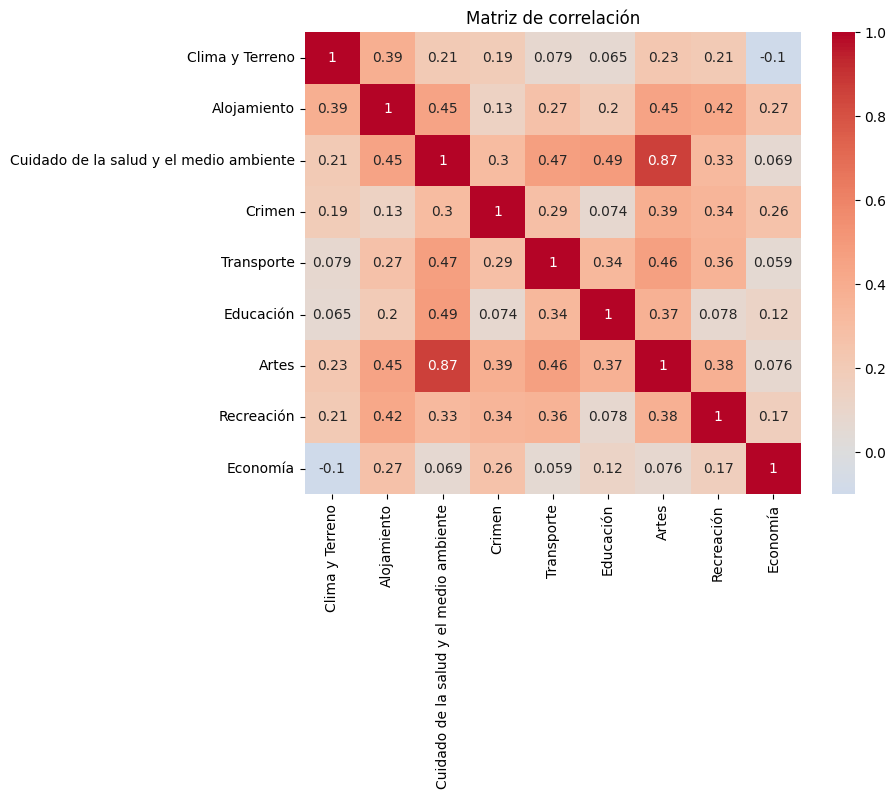

In [ ]:
# =========================================
# VISUALIZACIÓN DE CORRELACIONES
# =========================================

import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

In [ ]:
# Número de variables numéricas
k = df.select_dtypes(include='number').shape[1]

# Número de combinaciones bivariadas
num_graficas = k * (k - 1) // 2

num_graficas

36

Se realizó una exploración inicial del conjunto de datos compuesto por 329 ciudades y 9 variables que miden diferentes dimensiones de calidad de vida.Estas estadísticas son fundamentales porque permiten identificar diferencias de escala, variabilidad y relaciones entre variables, lo cual es clave para justificar la necesidad del PCA. Sin este análisis, no sería posible entender si existe redundancia o estructura latente en los datos. Algunas dimensiones presentan mayor dispersión que otras, lo cual indica que, para aplicar técnicas de reducción de dimensionalidad como PCA, es necesario estandarizar los datos para evitar que variables con mayor varianza dominen la construcción de los componentes principales.

Posteriormente, se analizó la matriz de correlación entre las variables. Se observan relaciones moderadas y fuertes entre algunas dimensiones como educación, transporte, recreación y alojamiento, lo que sugiere la existencia de información redundante entre variables. Esto indica que varias de estas dimensiones podrían estar midiendo aspectos comunes de la calidad de vida.

Por otro lado, variables como clima y economía presentan correlaciones bajas con el resto de dimensiones, lo cual sugiere que capturan aspectos más independientes dentro del concepto general de calidad de vida.

Adicionalmente, dado que existen 9 variables, el número de gráficos de dispersión bivariados posibles es:
$$
\frac{k(k-1)}{2} = \frac{9(9-1)}{2} = 36
$$


lo cual hace inviable un análisis visual exhaustivo de todas las relaciones bivariadas.

Estos resultados evidencian la presencia de redundancia en la información y una estructura subyacente de correlaciones entre variables. Por esta razón, el uso del Análisis de Componentes Principales (PCA) es apropiado, ya que permite reducir la dimensionalidad del problema, sintetizando la información en pocas componentes que capturan la mayor parte de la variabilidad de los datos y facilitando la interpretación de los factores latentes asociados a la calidad de vida en las ciudades. En este contexto, PCA permite aproximar dimensiones latentes como bienestar urbano o desarrollo social a partir de indicadores observados


### 3.  Cálculo y selección de componentes principales.

Utilizando Álgebra Lineal, calcule los eigen valores y los eigen vectores, a partir de ellos obtenga los Componentes Principales. Tenga en cuenta de estandarizar las variables y explicar por qué es importante no omitir este paso.

Luego, examine los valores propios para determinar cuántos componentes principales se deben considerar. Explique el criterio que utilizó para la elección y justifique su respuesta.

Rta: Se estandarizaron las variables para garantizar que todas tengan igual peso en el análisis, evitando que aquellas con mayor varianza o escala numérica dominen la construcción de los componentes principales.

In [ ]:
# =========================================
# CÁLCULO DE COMPONENTES PRINCIPALES
# =========================================

# Librerías necesarias
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Seleccionar solo variables numéricas (quitamos 'Ciudad')
X = df.select_dtypes(include='number')

# 2. Estandarizar las variables
# Esto convierte todas las variables a la misma escala (media 0, varianza 1)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# 3. Calcular matriz de covarianza
cov_matrix = np.cov(X_std, rowvar=False)

# 4. Calcular eigenvalores y eigenvectores
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# 5. Ordenar de mayor a menor
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Mostrar eigenvalores
eigenvalues

array([3.41868293, 1.21767731, 1.14495927, 0.9237255 , 0.75558148,
       0.63248434, 0.49455091, 0.31900812, 0.12076916])

In [ ]:
# Varianza explicada por cada componente
var_explained = eigenvalues / np.sum(eigenvalues)

# Varianza acumulada
var_acum = np.cumsum(var_explained)

var_acum

array([0.37869909, 0.51358533, 0.64041635, 0.74274055, 0.82643887,
       0.8965013 , 0.95128438, 0.98662199, 1.        ])

Se seleccionaron las variables numéricas del conjunto de datos y se estandarizaron con el fin de eliminar diferencias de escala y garantizar que todas las variables contribuyan de manera homogénea al análisis. Posteriormente, se construyó la matriz de covarianza a partir de los datos estandarizados y se aplicó descomposición espectral para obtener los eigenvalores y eigenvectores, los cuales permiten identificar las direcciones de máxima variabilidad en los datos.

Los eigenvalores fueron ordenados de mayor a menor para determinar la importancia relativa de cada componente principal. Los resultados muestran que el primer componente explica aproximadamente el 37.9% de la varianza total, seguido por el segundo y tercer componente con aportes adicionales menores. A partir del cuarto componente, la contribución marginal disminuye de forma significativa.

Bajo el criterio de Kaiser (eigenvalores mayores a 1), se retendrían tres componentes principales, lo cual indica que estos condensan las dimensiones más relevantes de los datos. Sin embargo, al analizar la varianza acumulada, se observa que cinco componentes principales explican aproximadamente el 82.6% de la variabilidad total, por lo que esta alternativa permite una representación más completa de la información.

En conclusión, aunque tres componentes son suficientes bajo un criterio estricto de eigenvalores, se opta por retener cinco componentes debido a su mayor capacidad explicativa. Esto evidencia redundancia en las variables originales y confirma la utilidad del PCA como técnica de reducción de dimensionalidad para simplificar la estructura del problema sin perder información relevante.

### 4.  Interpretación de los componentes principales.

Logró reducir la dimensión en el ejercicio anterior? Si lo hizo, pueden los pesos obtenidos identificar dimensiones menores de los datos? Provea una interpretación a estas dimensiones, para ello puede utilizar gráficas y/o tablas.

In [ ]:
## Construir una tabla de cargas (loadings):
import pandas as pd

# Nombres de variables
variables = df.select_dtypes(include='number').columns

# Crear DataFrame de cargas (eigenvectores)
loadings = pd.DataFrame(
    eigenvectors,
    columns=[f'CP{i+1}' for i in range(len(eigenvalues))],
    index=variables
)

loadings.iloc[:, :5]  # mostrar solo los primeros 5 componentes

,CP1,CP2,CP3,CP4,CP5
Clima y Terreno,0.206414,0.217835,0.689956,0.137321,-0.369150
Alojamiento,0.356522,0.250624,0.208172,0.511829,0.233488
Cuidado de la salud y el medio ambiente,0.460215,-0.299465,0.007325,0.014702,-0.103241
Crimen,0.281298,0.355342,-0.185105,-0.539050,-0.523940
Transporte,0.351151,-0.179604,-0.146376,-0.302904,0.404348
Educación,0.275293,-0.483382,-0.229703,0.335411,-0.208819
Artes,0.463054,-0.194790,0.026484,-0.101080,-0.105098
Recreación,0.327888,0.384475,0.050853,-0.189801,0.529541
Economía,0.135412,0.471283,-0.607314,0.421770,-0.159620


El primer componente agrupa principalmente variables asociadas al bienestar general urbano, mientras que otros componentes separan dimensiones como costo de vida, seguridad y servicios públicos. Esto confirma que la calidad de vida no es unidimensional.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.4/190.4 kB 11.7 MB/s eta 0:00:00


(<Figure size 2500x1500 with 1 Axes>,
 <Axes: title={'center': 'The top 2 Principal Component(s) explains [51.35%] of the variance.'}, xlabel='PC1 (37.8% expl.var)', ylabel='PC2 (13.4% expl.var)'>)

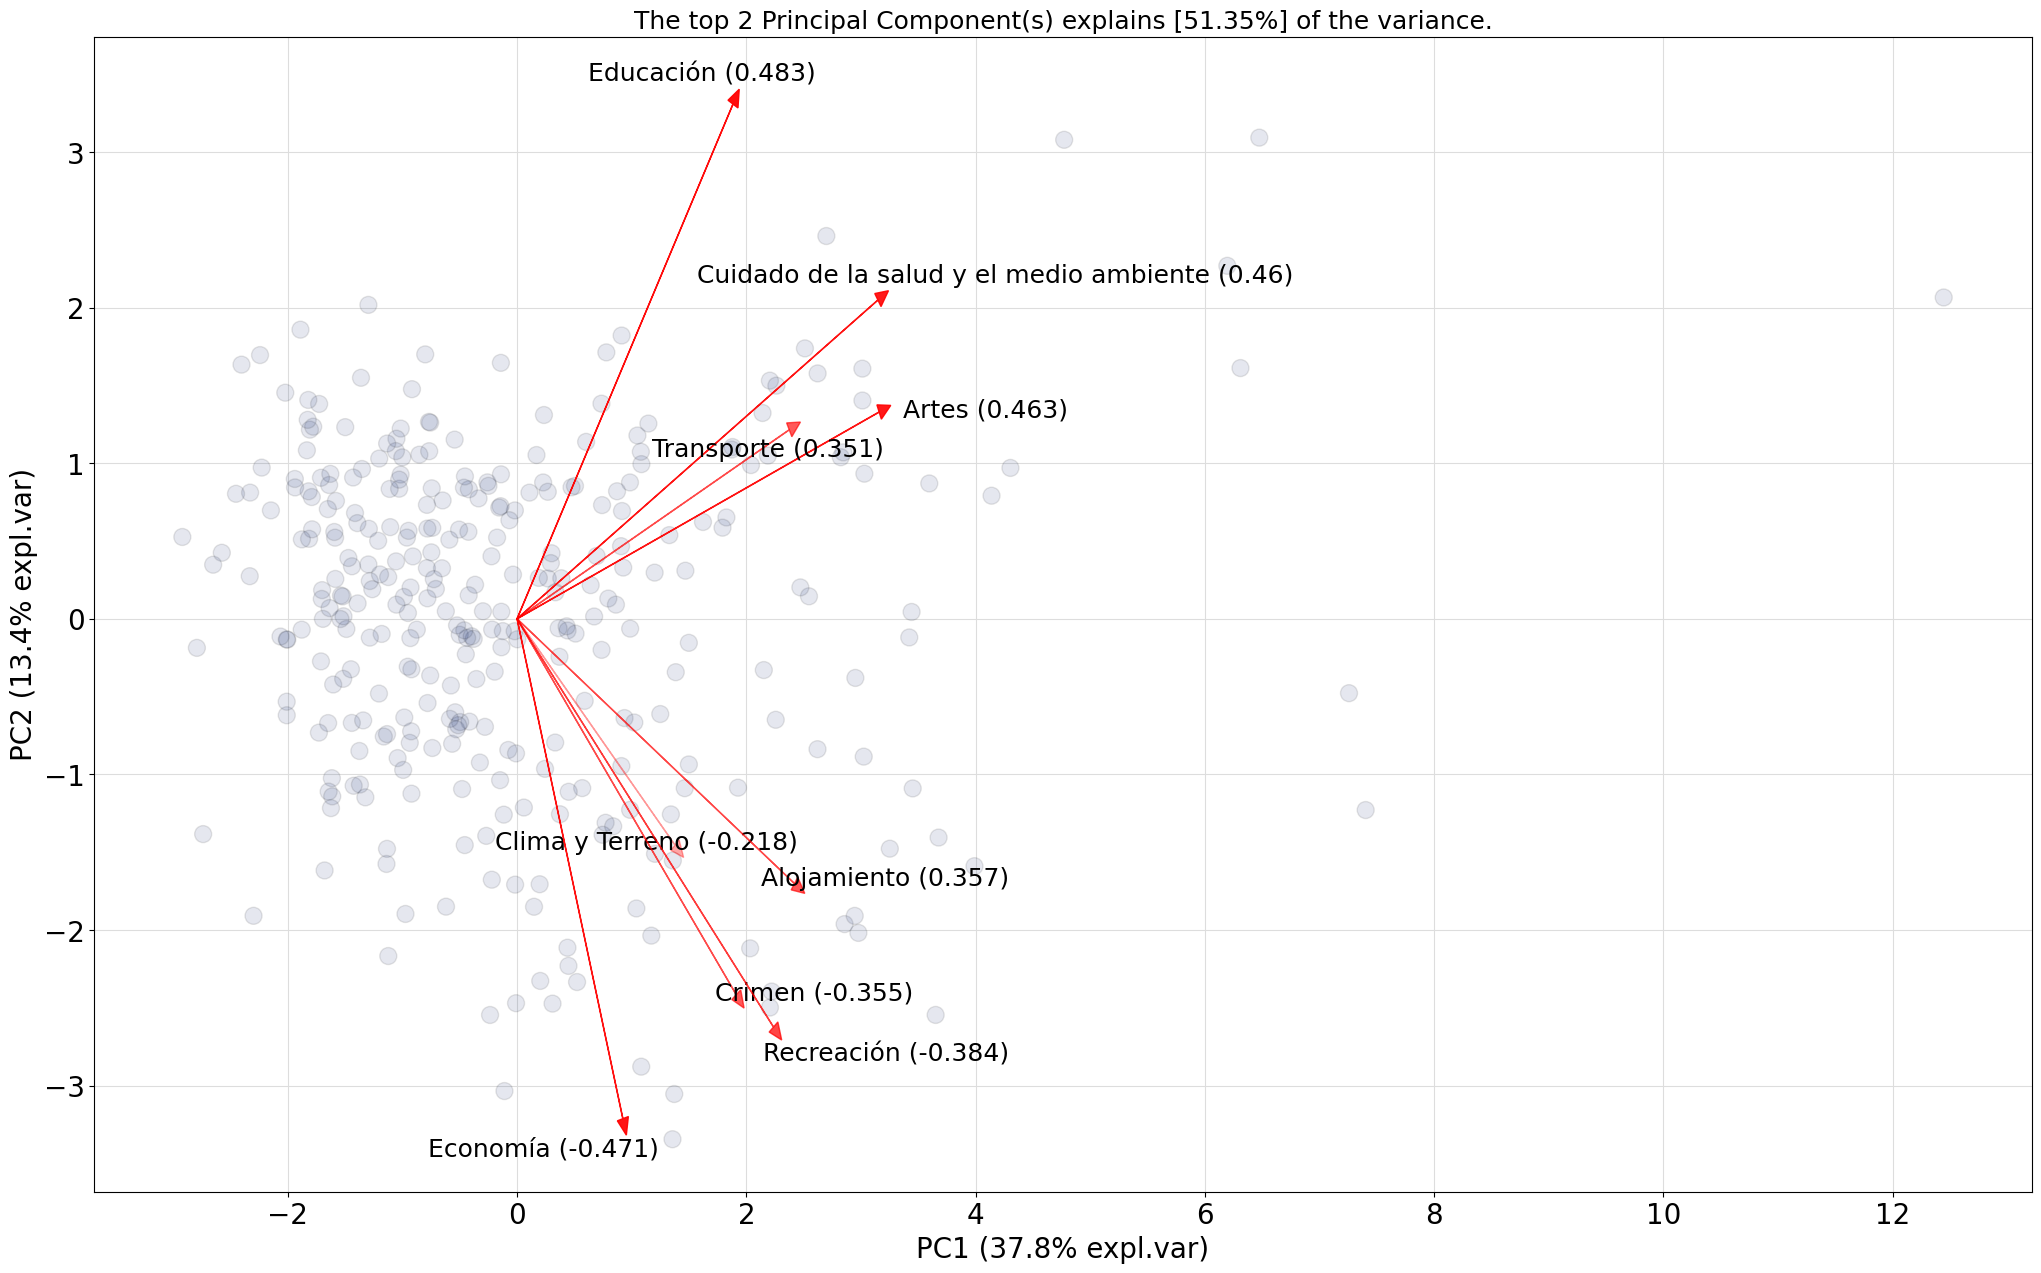

In [ ]:

# Instalar librería
!pip install pca

# Importar librería
from pca import pca

# Seleccionar variables numéricas
X = df.select_dtypes(include='number')

# Modelo PCA
model = pca(n_components=2, normalize=True, verbose=0)

# Ajustar modelo
results = model.fit_transform(X)

# Biplot
model.biplot(
    PC=[0, 1],
    alpha=0.1,
    legend=False,
    color_arrow="red",
    arrowdict={'color_text': "black"}
)

Se realizó un análisis de componentes principales (PCA) con el objetivo de reducir la dimensionalidad del conjunto de datos de calidad de vida en ciudades. Primero se seleccionaron las variables numéricas y se estandarizaron para evitar que las diferencias de escala afectaran el análisis. Luego se construyó la matriz de covarianza y se obtuvieron los eigenvalores y eigenvectores mediante descomposición espectral, los cuales se ordenaron para identificar los componentes principales. Finalmente, se calculó la varianza explicada y acumulada para evaluar cuánta información retenía cada componente.

Los resultados muestran que el primer componente explica cerca del 37.9% de la varianza total y que los primeros cinco componentes explican aproximadamente el 82.6% de la variabilidad, lo que permite reducir significativamente la dimensión del problema sin perder mucha información. La interpretación de los loadings indica que el primer componente refleja una medida general de calidad de vida, mientras que los siguientes capturan dimensiones como estructura socioeconómica, condiciones geográficas, costos urbanos y seguridad.

En conclusión, el PCA permite simplificar el conjunto de datos de forma efectiva y revelar estructuras latentes importantes, mostrando que la calidad de vida es un concepto multidimensional que no puede resumirse en una sola variable.

### 5.   Detección de ciudades inusuales.

A partir de los Componentes Principales identifique las 5 ciudades calidad de vida inusualmente alta. En la distribución de calidad de vida  de la muestra que tan inusuales son? Cuáles son las dimensiones que hacen que estas ciudades tengan esta calidad de vida inusual?

In [ ]:
# Librerías
import pandas as pd
from pca import pca

# Variables numéricas
X = df.select_dtypes(include='number')

# Nombre de ciudades
ciudades = df["Ciudad"]

# PCA
model = pca(n_components=2, normalize=True, verbose=0)
results = model.fit_transform(X)

# Extraer scores (componentes principales)
scores = results['PC']

# Agregar ciudades
scores['Ciudad'] = ciudades

# Ordenar por PC1
top5 = scores.sort_values(by='PC1', ascending=False).head(5)

top5

,PC1,PC2,Ciudad
212,12.445179,2.064887,"New-York,NY"
269,7.402662,-1.228869,"San-Francisco,CA"
178,7.257344,-0.477878,"Los-Angeles,Long-Beach,CA"
64,6.474759,3.091837,"Chicago,IL"
42,6.310655,1.611192,"Boston,MA"


Estas ciudades destacan principalmente por valores altos en el primer componente, el cual representa una combinación de condiciones socioeconómicas favorables, alta oferta de servicios, infraestructura desarrollada y oportunidades económicas. Adicionalmente, presentan valores extremos en el segundo componente, lo que indica diferencias en estructura urbana y costos de vida.

In [ ]:
import numpy as np

# omponentes principales
df_pca = scores.copy()

# distancia al origen (0,0)
df_pca['distancia'] = np.sqrt(df_pca['PC1']**2 + df_pca['PC2']**2)

# top 5 ciudades más inusuales
top5 = df_pca.sort_values('distancia', ascending=False).head(5)

top5

,PC1,PC2,Ciudad,distancia
212,12.445179,2.064887,"New-York,NY",12.615318
269,7.402662,-1.228869,"San-Francisco,CA",7.503967
178,7.257344,-0.477878,"Los-Angeles,Long-Beach,CA",7.273061
64,6.474759,3.091837,"Chicago,IL",7.175093
313,6.195895,2.268324,"Washington,DC-MD-VA",6.598061


Las ciudades seleccionadas se encuentran en el extremo superior de la distribución del primer componente principal, lo que indica que son casos atípicos con niveles de calidad de vida significativamente superiores al promedio. Su distancia al centro confirma su carácter inusual dentro de la muestra.

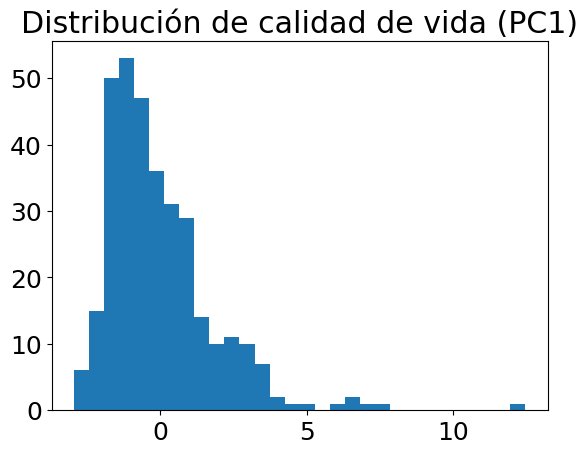

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df_pca['PC1'], bins=30)
plt.title("Distribución de calidad de vida (PC1)")
plt.show()

Las ciudades identificadas como más inusuales en términos de calidad de vida corresponden a New York, San Francisco, Los Angeles, Chicago y Washington D.C. Estas observaciones presentan los mayores valores de distancia en el espacio de componentes principales, lo que indica que se alejan significativamente del comportamiento promedio del conjunto de ciudades. Este resultado sugiere que no solo tienen niveles altos en algunas dimensiones, sino que también presentan combinaciones extremas de variables asociadas a costos de vida, oferta cultural, condiciones urbanas y estructura socioeconómica. En particular, estas ciudades tienden a destacarse simultáneamente en múltiples dimensiones, lo que las hace estructuralmente diferentes al resto de la muestra y explica su carácter atípico dentro del análisis de calidad de vida.